In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from google.colab import drive, userdata
import json
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

Libraries imported successfully!
TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
DATASET_DIR  = '/content/drive/MyDrive/Project_2k26/rice_disease_dataset'
MODEL_PATH   = '/content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras'
NAMES_PATH   = '/content/drive/MyDrive/Project_2k26/Phase3_outputs/class_names.json'
CLASS_NAMES  = ['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42
NUM_CLASSES  = len(CLASS_NAMES)

print(f"Dataset path  : {DATASET_DIR}")
print(f"Model path    : {MODEL_PATH}")
print(f"Classes       : {CLASS_NAMES}")

Dataset path  : /content/drive/MyDrive/Project_2k26/rice_disease_dataset
Model path    : /content/drive/MyDrive/Project_2k26/Phase3_outputs/best_model.keras
Classes       : ['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro']


In [4]:
# Load trained model
model = load_model(MODEL_PATH)
print("Model loaded successfully!")

# Load class names
with open(NAMES_PATH, 'r') as f:
    class_names_dict = json.load(f)

print(f"Class names loaded : {class_names_dict}")
print(f"Model input shape  : {model.input_shape}")
print(f"Model output shape : {model.output_shape}")

Model loaded successfully!
Class names loaded : {'0': 'Bacterialblight', '1': 'Blast', '2': 'Brownspot', '3': 'Healthy', '4': 'Tungro'}
Model input shape  : (None, 224, 224, 3)
Model output shape : (None, 5)


In [5]:
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    seed        = SEED,
    shuffle     = False
)

print(f"Validation samples : {val_gen.samples}")
print(f"Validation batches : {len(val_gen)}")
print(f"Class indices      : {val_gen.class_indices}")

Found 1442 images belonging to 5 classes.
Validation samples : 1442
Validation batches : 46
Class indices      : {'Bacterialblight': 0, 'Blast': 1, 'Brownspot': 2, 'Healthy': 3, 'Tungro': 4}


In [6]:
print("Generating predictions...")

val_gen.reset()
predictions  = model.predict(val_gen, verbose=1)
y_pred       = np.argmax(predictions, axis=1)
y_true       = val_gen.classes

print(f"Predictions shape  : {predictions.shape}")
print(f"Total predictions  : {len(y_pred)}")
print(f"Total true labels  : {len(y_true)}")

Generating predictions...
46/46 ━━━━━━━━━━━━━━━━━━━━ 813s 18s/step
Predictions shape  : (1442, 5)
Total predictions  : 1442
Total true labels  : 1442


In [7]:
overall_accuracy = accuracy_score(y_true, y_pred) * 100

print("=" * 45)
print("         OVERALL RESULTS")
print("=" * 45)
print(f"  Overall Accuracy : {overall_accuracy:.2f}%")
print("=" * 45)

         OVERALL RESULTS
  Overall Accuracy : 99.58%


In [8]:
report = classification_report(
    y_true,
    y_pred,
    target_names = CLASS_NAMES,
    digits       = 4
)

print("=" * 60)
print("          CLASSIFICATION REPORT")
print("=" * 60)
print(report)
print("=" * 60)

          CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Bacterialblight     1.0000    0.9937    0.9968       316
          Blast     1.0000    0.9861    0.9930       288
      Brownspot     0.9790    1.0000    0.9894       280
        Healthy     1.0000    1.0000    1.0000       297
         Tungro     1.0000    1.0000    1.0000       261

       accuracy                         0.9958      1442
      macro avg     0.9958    0.9960    0.9958      1442
   weighted avg     0.9959    0.9958    0.9958      1442



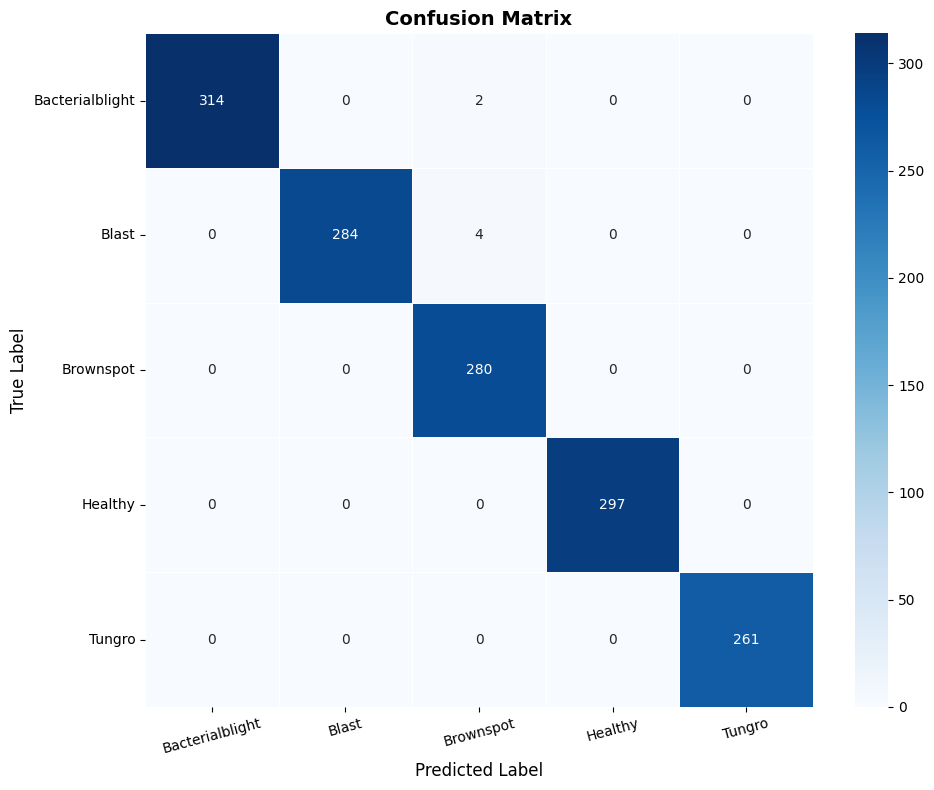

Confusion matrix saved!


In [9]:
save_dir = '/content/drive/MyDrive/Project_2k26/Phase4_outputs/'
os.makedirs(save_dir, exist_ok=True)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= CLASS_NAMES,
    yticklabels= CLASS_NAMES,
    linewidths = 0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.savefig(f'{save_dir}confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

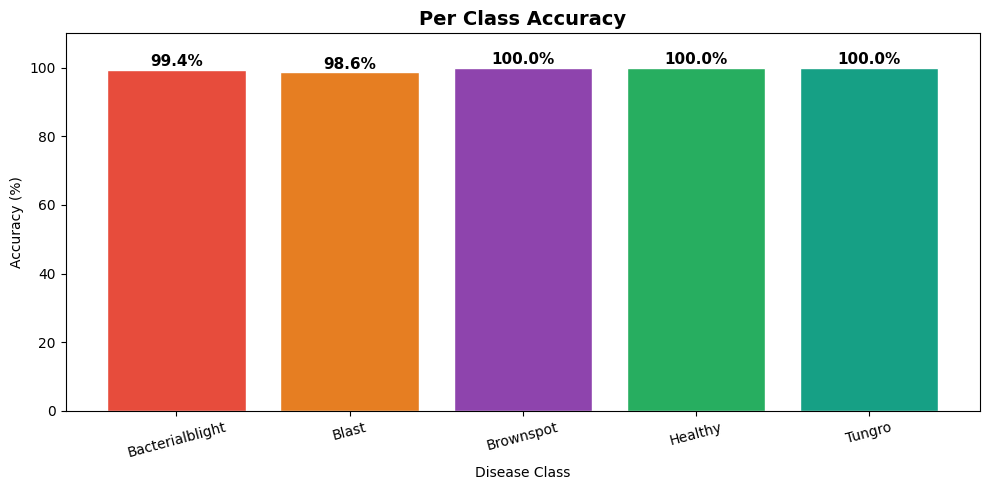

Per class accuracy chart saved!


In [10]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

colors = ['#e74c3c', '#e67e22', '#8e44ad', '#27ae60', '#16a085']

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASS_NAMES, per_class_accuracy,
               color=colors, edgecolor='white')

plt.title('Per Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.xticks(rotation=15)

for bar, val in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.savefig(f'{save_dir}per_class_accuracy.png', dpi=150)
plt.show()
print("Per class accuracy chart saved!")

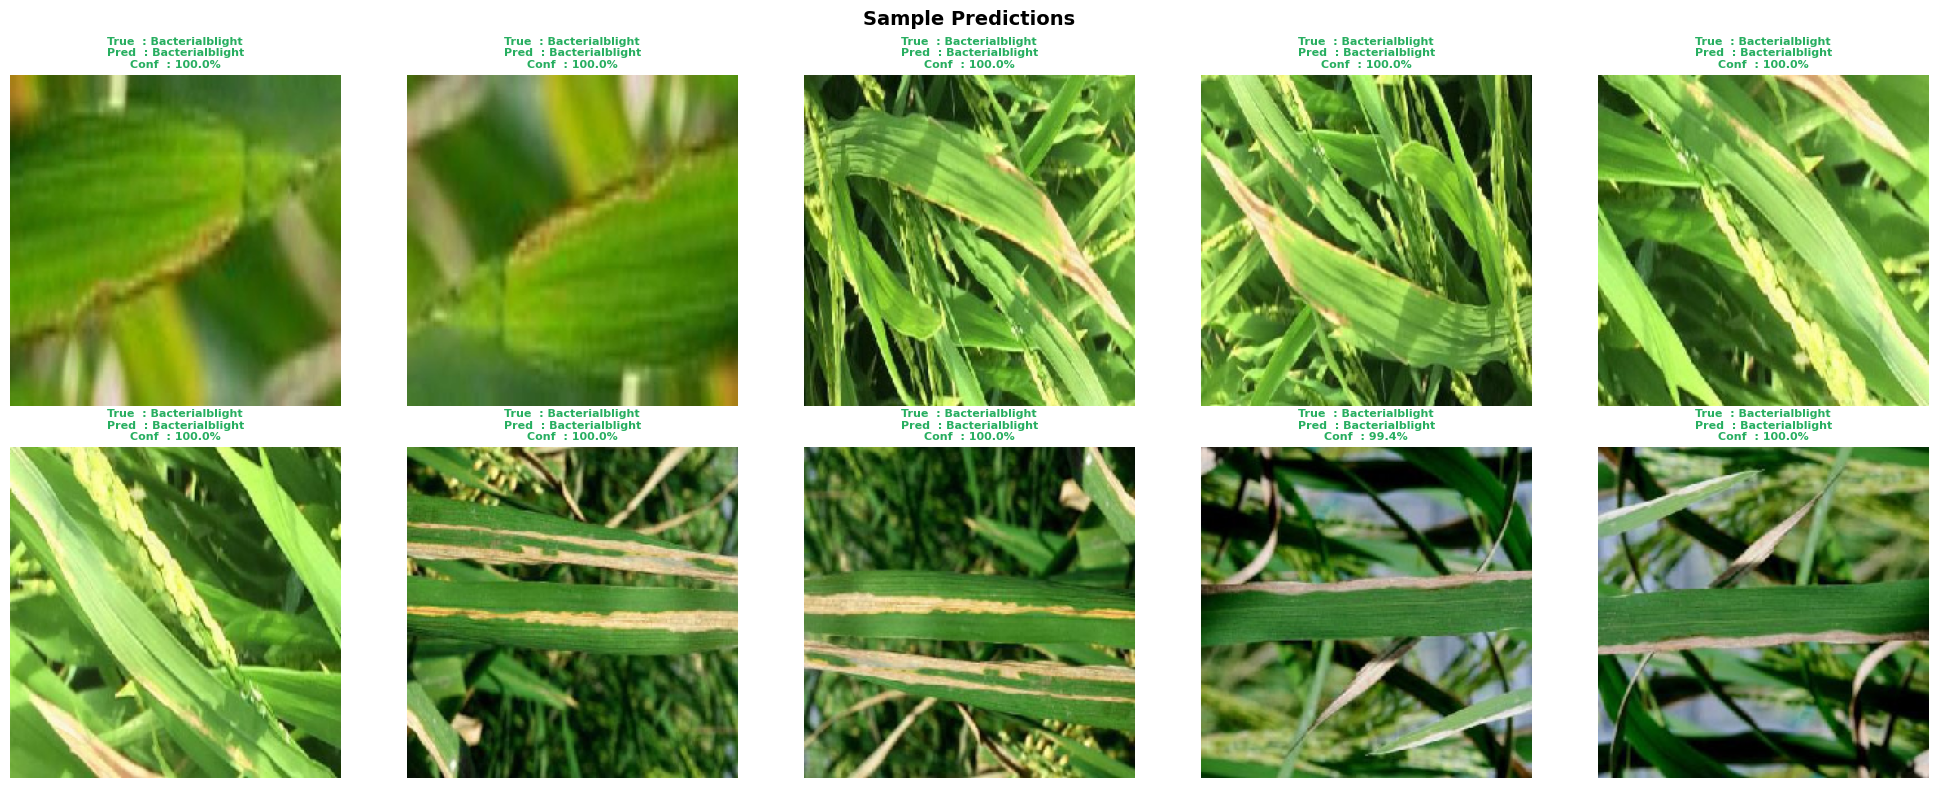

Sample predictions saved!
Green title = Correct prediction
Red title   = Wrong prediction


In [11]:
val_gen.reset()
images, labels_batch = next(val_gen)
preds                = model.predict(images[:10], verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Predictions', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    true_cls = CLASS_NAMES[np.argmax(labels_batch[i])]
    pred_cls = CLASS_NAMES[np.argmax(preds[i])]
    conf     = np.max(preds[i]) * 100

    color = '#27ae60' if true_cls == pred_cls else '#e74c3c'

    ax.set_title(
        f'True  : {true_cls}\nPred  : {pred_cls}\nConf  : {conf:.1f}%',
        fontsize=8,
        color=color,
        fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.savefig(f'{save_dir}sample_predictions.png', dpi=150)
plt.show()
print("Sample predictions saved!")
print("Green title = Correct prediction")
print("Red title   = Wrong prediction")

In [12]:
print("=" * 50)
print("         PHASE 4 EVALUATION SUMMARY")
print("=" * 50)
print(f"  Overall Accuracy     : {overall_accuracy:.2f}%")
print()
print("  Per Class Accuracy:")
for cls, acc in zip(CLASS_NAMES, per_class_accuracy):
    print(f"    {cls:<22} : {acc:.2f}%")
print()
print("  Output Files:")
print(f"    confusion_matrix.png")
print(f"    per_class_accuracy.png")
print(f"    sample_predictions.png")
print(f"  Saved to : {save_dir}")
print("=" * 50)

         PHASE 4 EVALUATION SUMMARY
  Overall Accuracy     : 99.58%

  Per Class Accuracy:
    Bacterialblight        : 99.37%
    Blast                  : 98.61%
    Brownspot              : 100.00%
    Healthy                : 100.00%
    Tungro                 : 100.00%

  Output Files:
    confusion_matrix.png
    per_class_accuracy.png
    sample_predictions.png
  Saved to : /content/drive/MyDrive/Project_2k26/Phase4_outputs/
